In [1]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

#load dataset
df = pd.read_csv("encoded_attrition_data.csv")
df.head()

,age,seniority,tenure,monthly_income,satisfaction_score,work_life_balance,overtime,commute_distance,promotion_last_5yrs,performance_score,trg_hrs_last_year,attrition,department_Engineering,department_Finance,department_HR,department_IT,department_Marketing,department_Operations,department_Sales
0,42,3,9,9866,4,1,0,24.5,1,4,19,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,36,3,7,8958,3,3,0,10.0,0,2,13,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,44,4,16,11716,4,3,0,4.0,0,4,13,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,53,4,30,17061,5,3,0,7.1,0,3,20,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,35,2,4,5738,2,3,0,8.4,0,2,15,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [2]:
#Isolate target variables
y = df['attrition']
X = df.drop('attrition', axis=1)


In [3]:
#train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [6]:
#Logistic Regression Model
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
#Print classification report for Logistic regression model
pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.94      0.63      0.75      1819
           1       0.14      0.61      0.23       181

    accuracy                           0.63      2000
   macro avg       0.54      0.62      0.49      2000
weighted avg       0.87      0.63      0.71      2000



In [10]:
#Coefficients vs Features
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
6,overtime,0.702865
16,department_Operations,0.317630
17,department_Sales,0.244512
15,department_Marketing,0.240971
14,department_IT,0.097824
11,department_Engineering,0.085707
12,department_Finance,0.013047
0,age,0.008847
10,trg_hrs_last_year,0.008236
7,commute_distance,0.007649


In [13]:
#Instantiate Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
rf_pred = rf.predict(X_test)
print(accuracy_score(y_test, rf_pred))

0.8635


In [15]:
#Print classification report for Random Forest model
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1819
           1       0.20      0.17      0.19       181

    accuracy                           0.86      2000
   macro avg       0.56      0.55      0.56      2000
weighted avg       0.85      0.86      0.86      2000



In [16]:
#Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

                   Feature  Importance
3           monthly_income    0.158199
7         commute_distance    0.145217
0                      age    0.105834
4       satisfaction_score    0.104093
2                   tenure    0.103095
10       trg_hrs_last_year    0.094686
5        work_life_balance    0.067663
9        performance_score    0.040664
1                seniority    0.040630
6                 overtime    0.038591
11  department_Engineering    0.014258
17        department_Sales    0.013964
8      promotion_last_5yrs    0.013398
15    department_Marketing    0.013086
16   department_Operations    0.012897
14           department_IT    0.011562
13           department_HR    0.011409
12      department_Finance    0.010753


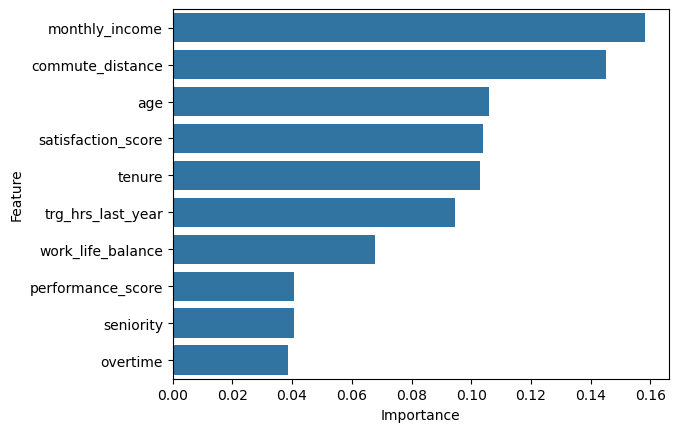

In [17]:
#Visualisations for Random Forest and Logistic Regression models
import piplite
await piplite.install('seaborn')
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x='Importance', y='Feature', data=importance.head(10))
plt.show()

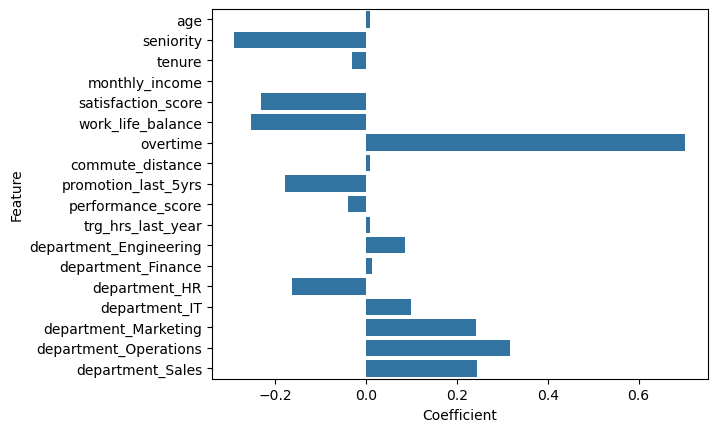

In [18]:
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.show()

Text(0, 0.5, 'True Positive Rate')

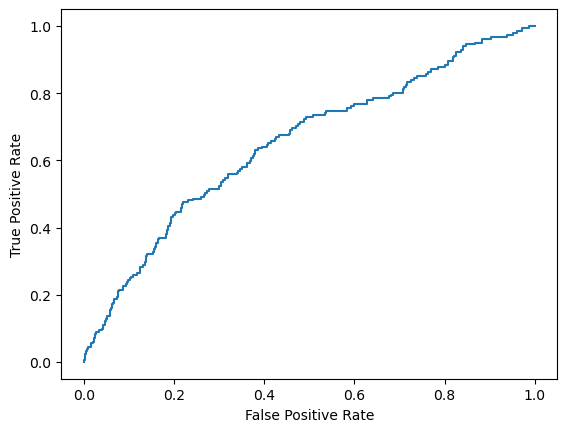

In [19]:
#ROC Curve
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

In [20]:
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.649844034272975


In [40]:
#Prepare dateset for Tableau
df1 = pd.read_csv("Employee_Attrition_DataSet.csv")
df1['attrition_probability'] = model.predict_proba(X)[:,1]
df1.head()

,EmployeeID,age,department,seniority,tenure,monthly_income,satisfaction_score,work_life_balance,overtime,commute_distance,promotion_last_5yrs,performance_score,trg_hrs_last_year,attrition,attrition_probability
0,EMP0000,42,Sales,3,9,9866,4,1,No,24.5,Yes,4,19,No,0.468369
1,EMP0001,36,Sales,3,7,8958,3,3,No,10.0,No,2,13,No,0.410609
2,EMP0002,44,Sales,4,16,11716,4,3,No,4.0,No,4,13,No,0.266021
3,EMP0003,53,Finance,4,30,17061,5,3,No,7.1,No,3,20,No,0.210588
4,EMP0004,35,HR,2,4,5738,2,3,No,8.4,No,2,15,No,0.401594


In [41]:
#Define function to group employees by risk catrgory for attrition
def risk_group(prob):
    
    if prob >= 0.6:
        return "High Risk"
    
    elif prob >= 0.3:
        return "Medium Risk"
    
    else:
        return "Low Risk"


df1['risk_category'] = df1['attrition_probability'].apply(risk_group)

In [42]:
df1['risk_category'].value_counts()

risk_category
Medium Risk    7432
High Risk      1675
Low Risk        893
Name: count, dtype: int64

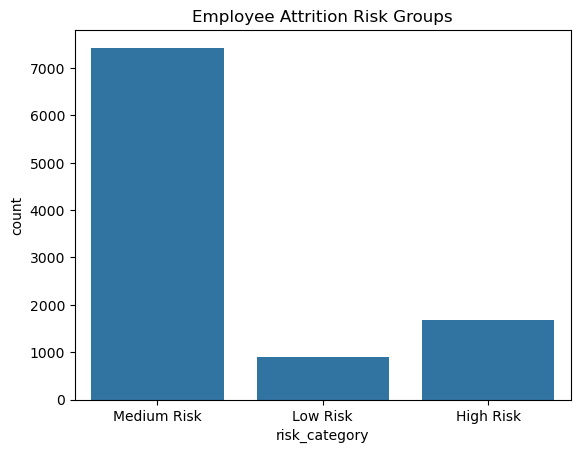

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='risk_category', data=df1)
plt.title("Employee Attrition Risk Groups")
plt.show()

In [45]:
df1['attrition'] = df1['attrition'].replace({'No':0,'Yes':1})
df1.head()

<ipython-input-45-929de2880528>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['attrition'] = df1['attrition'].replace({'No':0,'Yes':1})


,EmployeeID,age,department,seniority,tenure,monthly_income,satisfaction_score,work_life_balance,overtime,commute_distance,promotion_last_5yrs,performance_score,trg_hrs_last_year,attrition,attrition_probability,risk_category
0,EMP0000,42,Sales,3,9,9866,4,1,No,24.5,Yes,4,19,0,0.468369,Medium Risk
1,EMP0001,36,Sales,3,7,8958,3,3,No,10.0,No,2,13,0,0.410609,Medium Risk
2,EMP0002,44,Sales,4,16,11716,4,3,No,4.0,No,4,13,0,0.266021,Low Risk
3,EMP0003,53,Finance,4,30,17061,5,3,No,7.1,No,3,20,0,0.210588,Low Risk
4,EMP0004,35,HR,2,4,5738,2,3,No,8.4,No,2,15,0,0.401594,Medium Risk


In [46]:
#Dataset is ready for Tableau
tableau = df1.copy()
tableau.to_csv(
    "attrition_tableau.csv",
    index=False
)